<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Credit_Card_Cutomers_using_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Credit Card Customers Segmentation**

##We Have dataset that consists of 10,000 customers mentioning their age, salary, marital_status, credit card limit, credit card category, etc. There are nearly 20 features.

In [ ]:
import pandas as pd
import zipfile
import os

# Define the path to the zip file
zip_file_path = '/content/BankChurners.csv.zip'

# Define the directory to extract to
extract_dir = '/content/'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

# Load the extracted CSV file into a pandas DataFrame
csv_file_path = os.path.join(extract_dir, 'BankChurners.csv')
df = pd.read_csv(csv_file_path)

'/content/BankChurners.csv.zip' extracted to '/content/'


In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## **Data Preprocessing**

In [ ]:
# Drop the specified columns
columns_to_drop = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]

df = df.drop(columns=columns_to_drop)

# Display the first 5 rows of the DataFrame after dropping columns
display(df.head())

KeyError: "['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'] not found in axis"

In [ ]:
df.isna().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


##Remove redundant features
 * Removing features like Total_Revolving_Bal, Avg_Open_To_Buy	0, Total_Amt_Chng_Q4_Q1, Total_Ct_Chng_Q4_Q1 because they are methamatically correlated with features like Credit Limit, Avg_Utilization Ratio, Total Transactions.
 * Removing Card type and Attrition Flag features because it is not required.

In [ ]:
df = df[['CLIENTNUM', 'Customer_Age', 'Gender',
        'Dependent_count', 'Education_Level', 'Marital_Status',
        'Income_Category',  'Months_on_book',
        'Total_Relationship_Count', 'Months_Inactive_12_mon',
          'Credit_Limit',
          'Total_Trans_Amt',
        'Total_Trans_Ct',  'Avg_Utilization_Ratio',
          ]]
df

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,768805383,45,M,3,High School,Married,$60K - $80K,39,5,1,12691.0,1144,42,0.061
1,818770008,49,F,5,Graduate,Single,Less than $40K,44,6,1,8256.0,1291,33,0.105
2,713982108,51,M,3,Graduate,Married,$80K - $120K,36,4,1,3418.0,1887,20,0.000
3,769911858,40,F,4,High School,Unknown,Less than $40K,34,3,4,3313.0,1171,20,0.760
4,709106358,40,M,3,Uneducated,Married,$60K - $80K,21,5,1,4716.0,816,28,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,50,M,2,Graduate,Single,$40K - $60K,40,3,2,4003.0,15476,117,0.462
10123,710638233,41,M,2,Unknown,Divorced,$40K - $60K,25,4,2,4277.0,8764,69,0.511
10124,716506083,44,F,1,High School,Married,Less than $40K,36,5,3,5409.0,10291,60,0.000
10125,717406983,30,M,2,Graduate,Unknown,$40K - $60K,36,4,3,5281.0,8395,62,0.000


## Rename the columns for better understanding features

In [ ]:
df.columns = ['customer_id', 'age', 'gender', 'dependent_count', 'education_level', 'marital_status', 'estimated_income', 'months_on_book',
              'total_relationship_count','months_inactive_12_mon','credit_Limit','total_trans_amount','total_trans_count','avg_utilization_ratio']

In [ ]:
df.describe()

,customer_id,age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,credit_Limit,total_trans_amount,total_trans_count,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,8631.953698,4404.086304,64.858695,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,9088.776650,3397.129254,23.472570,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,1438.300000,510.000000,10.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2555.000000,2155.500000,45.000000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,4549.000000,3899.000000,67.000000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,11067.500000,4741.000000,81.000000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,34516.000000,18484.000000,139.000000,0.999000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  object 
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  object 
 5   marital_status            10127 non-null  object 
 6   estimated_income          10127 non-null  object 
 7   months_on_book            10127 non-null  int64  
 8   total_relationship_count  10127 non-null  int64  
 9   months_inactive_12_mon    10127 non-null  int64  
 10  credit_Limit              10127 non-null  float64
 11  total_trans_amount        10127 non-null  int64  
 12  total_trans_count         10127 non-null  int64  
 13  avg_utilization_ratio     10127 non-null  float64
dtypes: flo

In [ ]:
df['estimated_income'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'Unknown'], dtype=object)

## Convert Income columns to Numerical

In [ ]:
import numpy as np
def parse_income(val):
    if val == 'Unknown':
        return np.nan
    if 'Less than' in val:
        return 20_000  # midpoint of 0-40K
    if '+' in val:
        return 140_000  # midpoint estimate for 120K+
    # e.g. '$60K - $80K'
    low, high = val.replace('$','').replace('K','').split(' - ')
    return (int(low) + int(high)) / 2 * 1000

df['income_numeric'] = df['estimated_income'].apply(parse_income)

In [ ]:
df

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_Limit,total_trans_amount,total_trans_count,avg_utilization_ratio,income_numeric
0,768805383,45,M,3,High School,Married,$60K - $80K,39,5,1,12691.0,1144,42,0.061,70000.0
1,818770008,49,F,5,Graduate,Single,Less than $40K,44,6,1,8256.0,1291,33,0.105,20000.0
2,713982108,51,M,3,Graduate,Married,$80K - $120K,36,4,1,3418.0,1887,20,0.000,100000.0
3,769911858,40,F,4,High School,Unknown,Less than $40K,34,3,4,3313.0,1171,20,0.760,20000.0
4,709106358,40,M,3,Uneducated,Married,$60K - $80K,21,5,1,4716.0,816,28,0.000,70000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,50,M,2,Graduate,Single,$40K - $60K,40,3,2,4003.0,15476,117,0.462,50000.0
10123,710638233,41,M,2,Unknown,Divorced,$40K - $60K,25,4,2,4277.0,8764,69,0.511,50000.0
10124,716506083,44,F,1,High School,Married,Less than $40K,36,5,3,5409.0,10291,60,0.000,20000.0
10125,717406983,30,M,2,Graduate,Unknown,$40K - $60K,36,4,3,5281.0,8395,62,0.000,50000.0


In [ ]:
df= df.drop(columns=['estimated_income'])

## **Data Visualization**

/tmp/ipykernel_68789/391075725.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
/tmp/ipykernel_68789/391075725.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


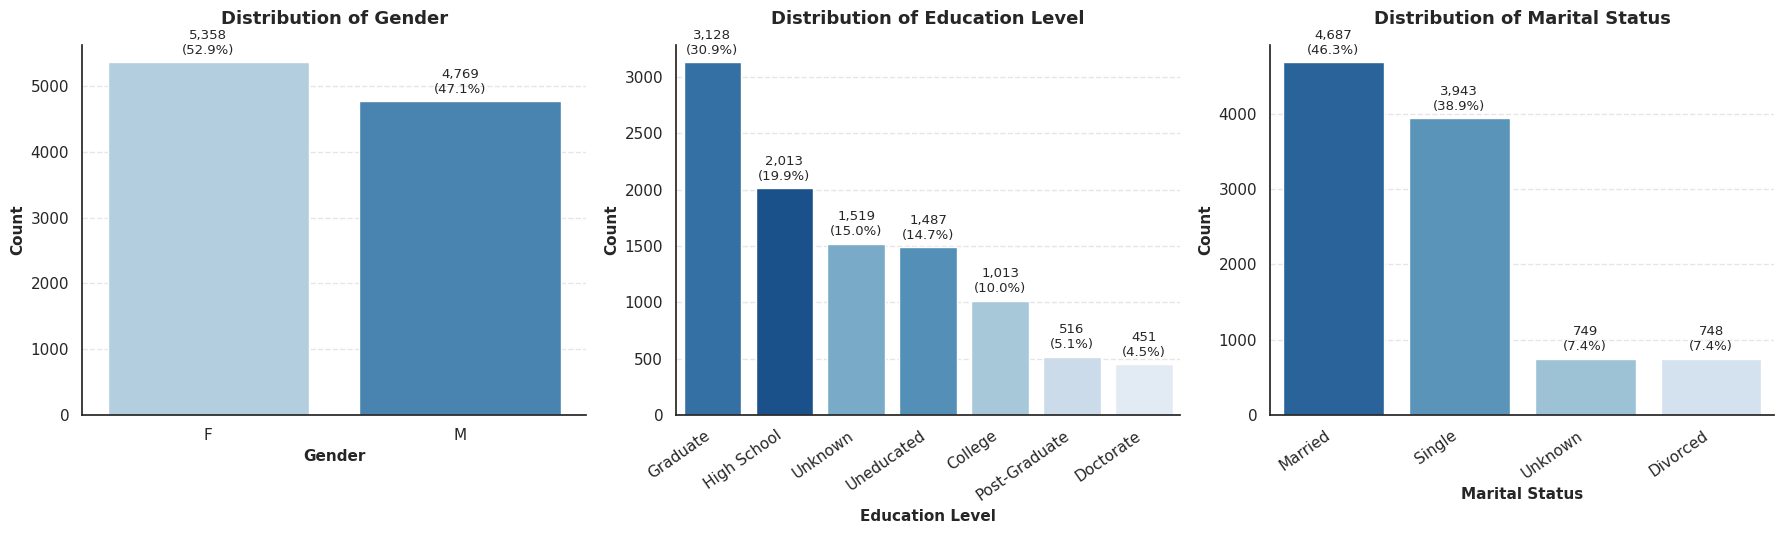

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="white", font_scale=1.0)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

categorical_cols = [
    ("gender", "Distribution of Gender", "Gender"),
    ("education_level", "Distribution of Education Level", "Education Level"),
    ("marital_status", "Distribution of Marital Status", "Marital Status"),
]

total_rows = len(df)

for i, (col, title, x_label) in enumerate(categorical_cols):
    ax = axes[i]

    # Order categories by frequency (highest count first)
    col_order = df[col].value_counts().index

    # Plot chart
    sns.countplot(
        data=df,
        x=col,
        order=col_order,
        palette="Blues_r",
        hue=col,
        legend=False,
        ax=ax,
    )

    # Title & Axis Formatting
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.set_xlabel(x_label, fontsize=11, fontweight="semibold")
    ax.set_ylabel("Count", fontsize=11, fontweight="semibold")

    # Rotate labels nicely if text is long
    if col != "gender":
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

    # Annotate bars with Count and Percentage
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f"{(height / total_rows) * 100:.1f}%"
            ax.annotate(
                f"{int(height):,}\n({percentage})",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9.5,
                xytext=(0, 4),
                textcoords="offset points",
            )

    # Visual cleanup
    sns.despine(ax=ax)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

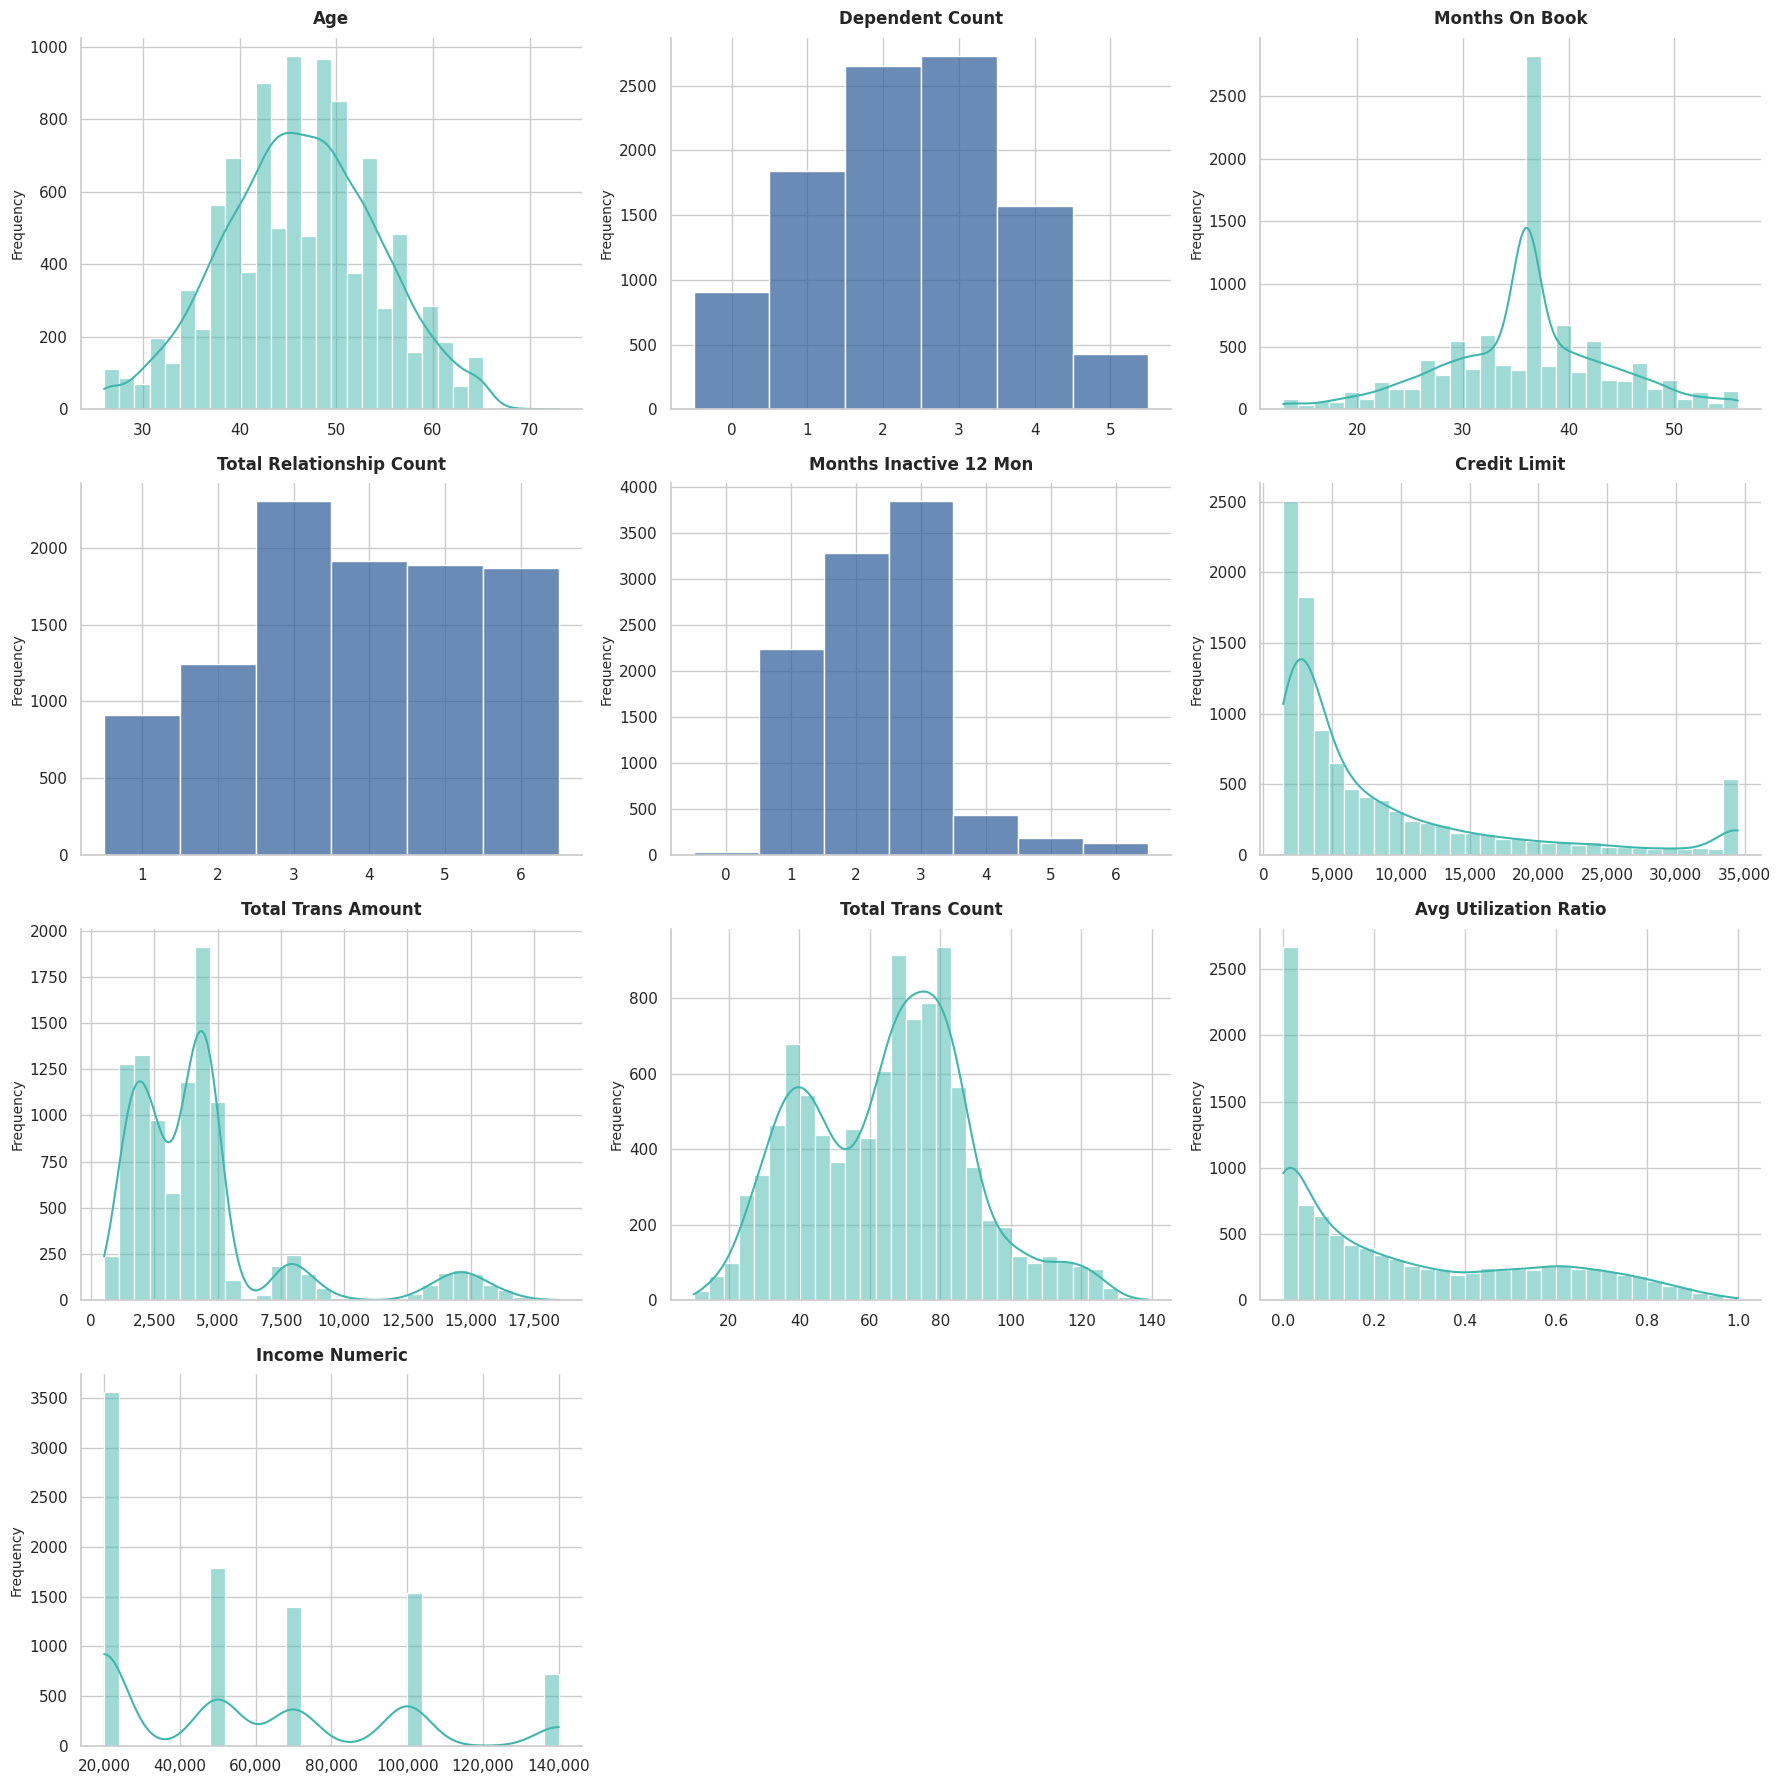

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Set overall theme
sns.set_theme(style='whitegrid', palette='mako')

numerical_cols = [
    'age', 'dependent_count', 'months_on_book', 'total_relationship_count',
    'months_inactive_12_mon', 'credit_Limit', 'total_trans_amount',
    'total_trans_count', 'avg_utilization_ratio', 'income_numeric'
]

# Identify variables that are discrete (whole numbers with a narrow range)
discrete_cols = ['dependent_count', 'total_relationship_count', 'months_inactive_12_mon']

num_cols = 3
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    is_discrete = col in discrete_cols

    # Plot dynamically based on data type
    sns.histplot(
        data=df,
        x=col,
        kde=not is_discrete,     # Turn off KDE for discrete integer variables
        discrete=is_discrete,    # Snap bins to whole numbers if discrete
        bins=30 if not is_discrete else None,
        ax=ax,
        color=sns.color_palette("mako")[2] if is_discrete else sns.color_palette("mako")[4]
    )

    # Clean up titles
    clean_title = col.replace('_', ' ').title()
    ax.set_title(clean_title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency', fontsize=10)

    # Format x-axis with commas for large numerical ranges
    if col in ['credit_Limit', 'total_trans_amount', 'income_numeric']:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

# Remove unused subplots seamlessly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

sns.despine()
plt.tight_layout()
plt.show()

* Age: Most customers are middle-aged, typically between 40 and 50 years old.

* Dependents: The majority of people have 2 or 3 dependents.

* Time as a Customer (Months on book): There is a huge spike at 36 months, meaning a very large number of people have been customers for exactly 3 years.

* Bank Relationships: Most customers use 3 or more different products from the bank.

* Credit Limit: Most people have lower credit limits (under 5,000). Only a small group has a very high limit (around 35,000).

* Transaction Amount: Most people spend a total of around 4,000 to 5,000, but there are distinct smaller groups that spend much more (around 8,000 and 15,000).

* Transaction Count: Customers generally make around 40 or 80 transactions, forming two main groups.

* Credit Use (Utilization Ratio): Most people keep their balance very low compared to their limit; the ratio is mostly near zero.

* Income: A large portion of customers fall into the lowest recorded income bracket (around 20,000), while the rest are grouped into specific higher income buckets.

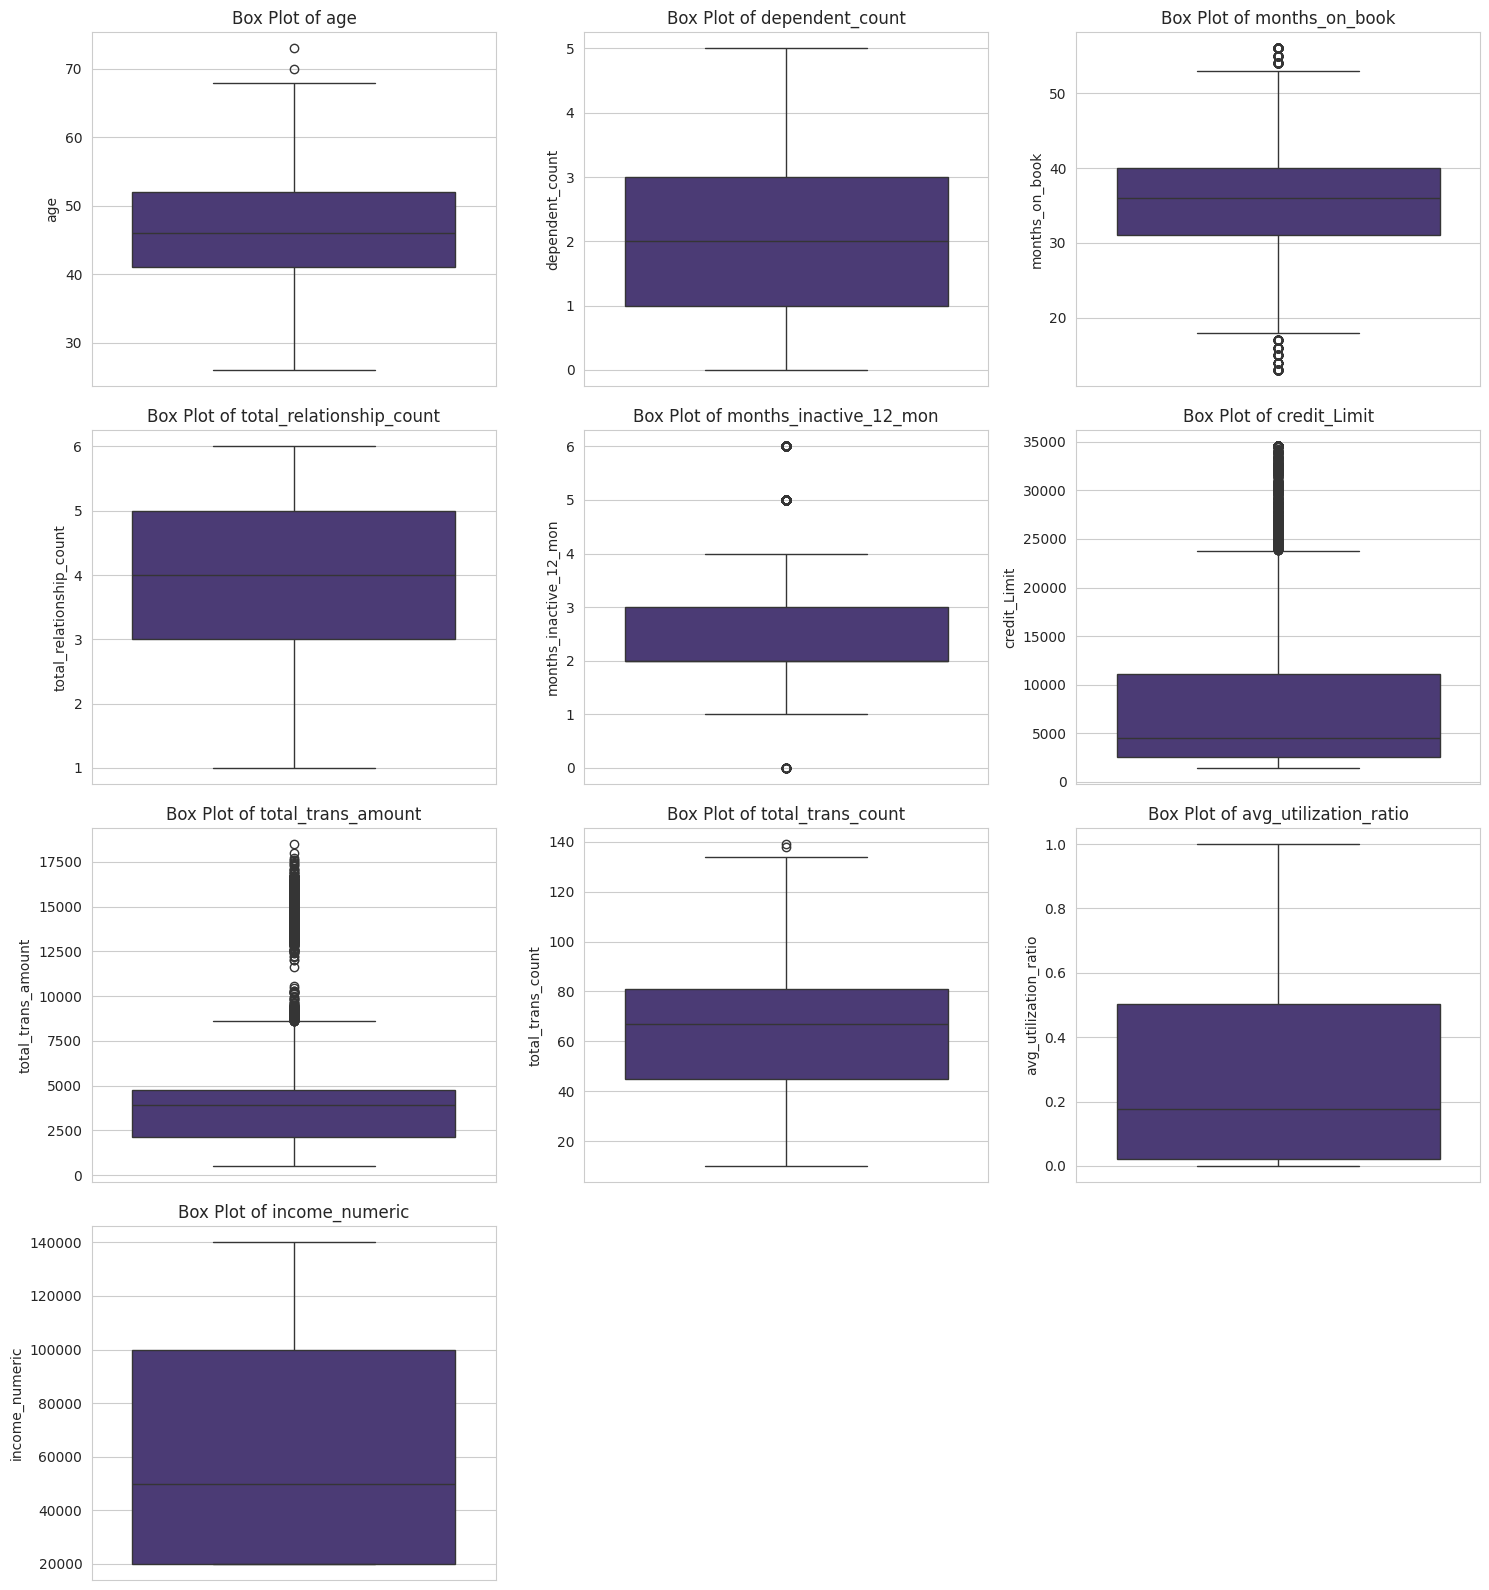

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for box plots (same as for histograms)
numerical_cols = [
    'age',
    'dependent_count',
    'months_on_book',
    'total_relationship_count',
    'months_inactive_12_mon',
    'credit_Limit',
    'total_trans_amount',
    'total_trans_count',
    'avg_utilization_ratio',
    'income_numeric'
]

# Determine the number of rows and columns for subplots
num_cols = 3 # You can adjust this for desired layout
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette('viridis')[0])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

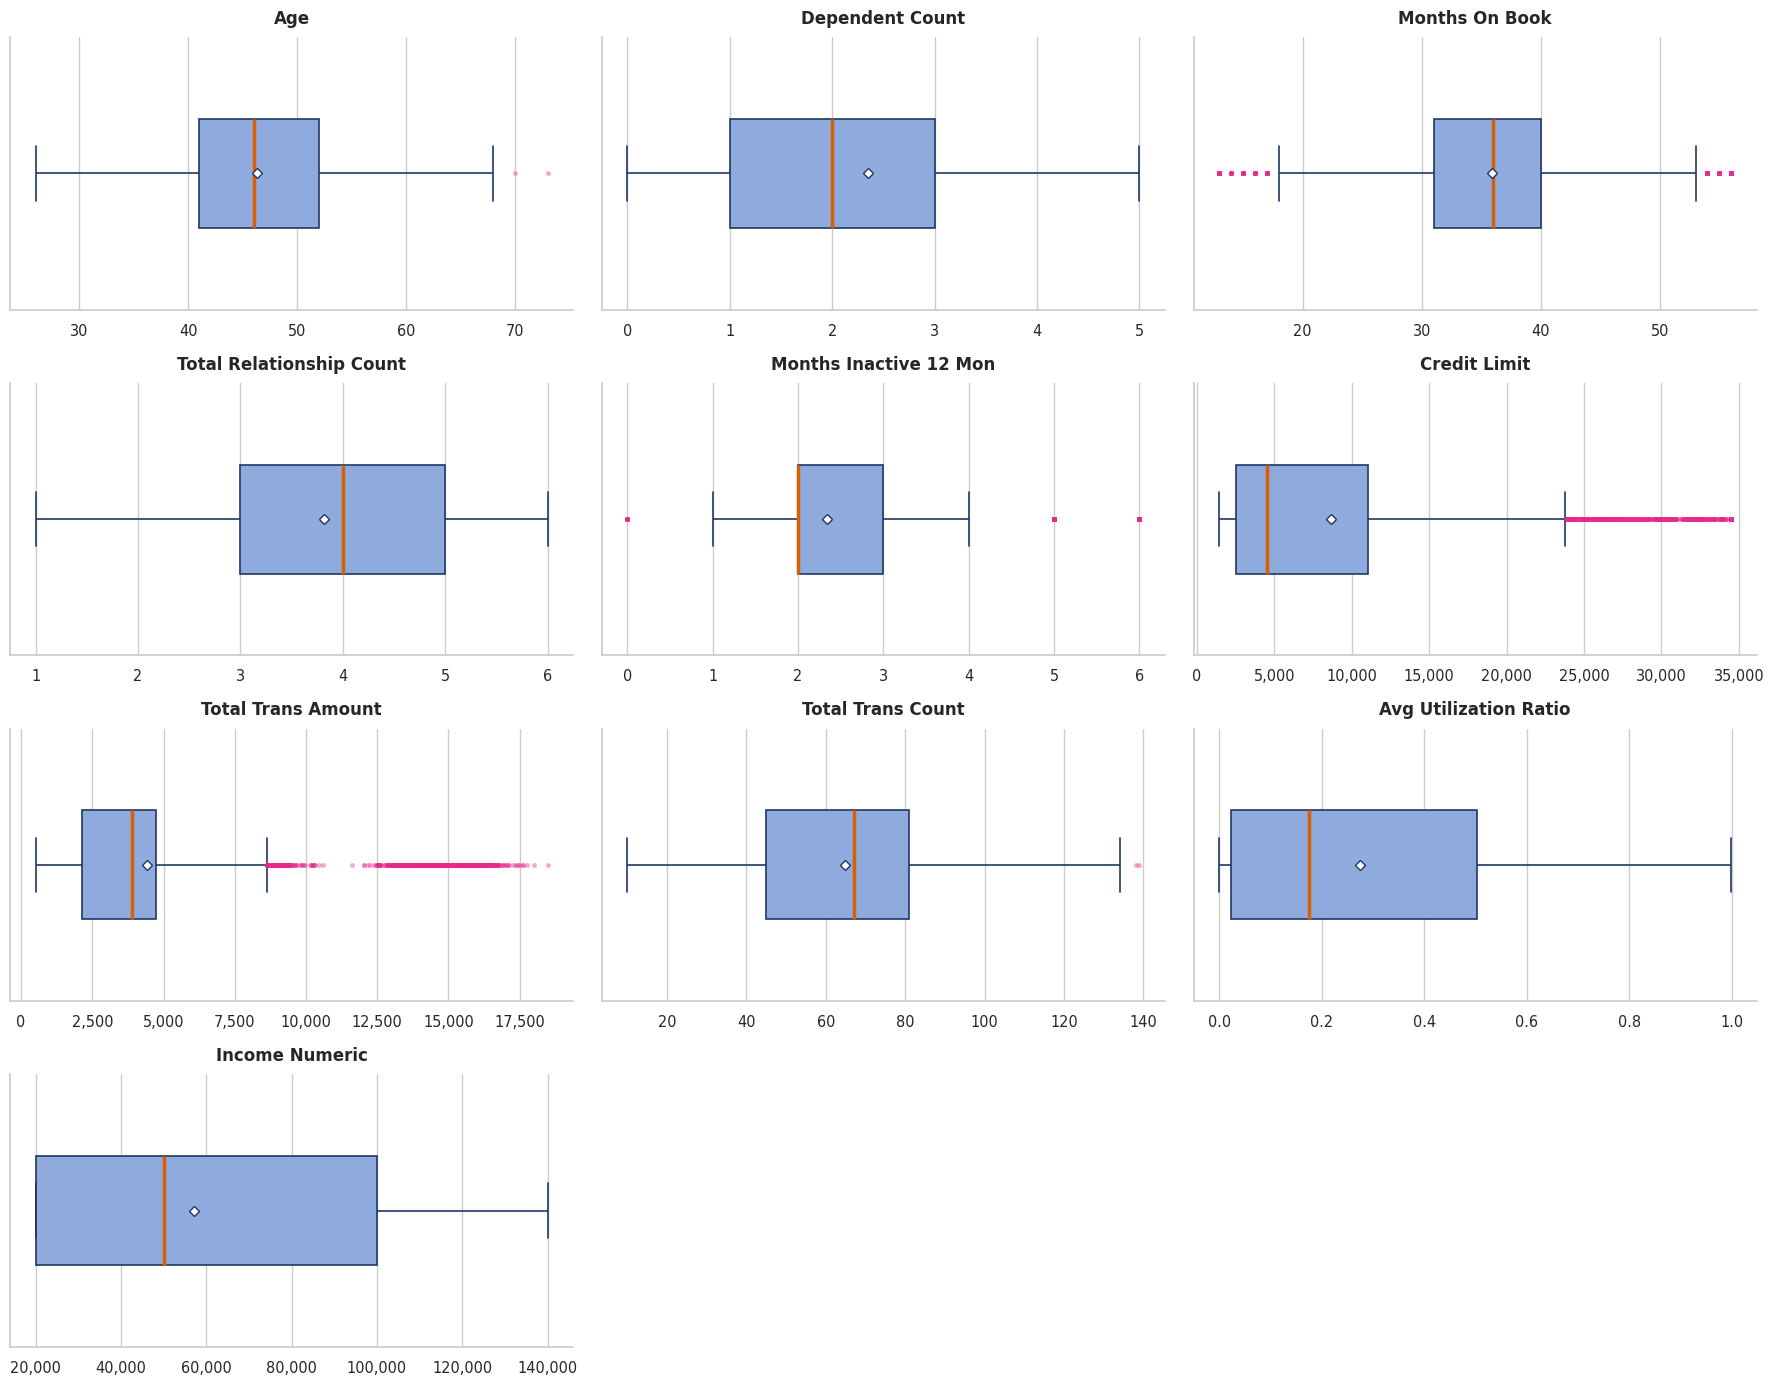

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Set overall style
sns.set_theme(style='whitegrid', font_scale=0.95)

numerical_cols = [
    'age',
    'dependent_count',
    'months_on_book',
    'total_relationship_count',
    'months_inactive_12_mon',
    'credit_Limit',
    'total_trans_amount',
    'total_trans_count',
    'avg_utilization_ratio',
    'income_numeric'
]

num_cols = 3
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 3.5))
axes = axes.flatten()

# Custom box plot styling for maximum contrast and clean outliers
box_style = {
    'boxprops': {'facecolor': '#8FAADC', 'edgecolor': '#203764', 'linewidth': 1.2},
    'medianprops': {'color': '#D95F02', 'linewidth': 2.5},  # Bold orange median line
    'whiskerprops': {'color': '#203764', 'linewidth': 1.2},
    'capprops': {'color': '#203764', 'linewidth': 1.2},
    'flierprops': {
        'marker': 'o',
        'markersize': 3.5,
        'markerfacecolor': '#E7298A',
        'markeredgecolor': 'none',
        'alpha': 0.4
    } # Semi-transparent pink outliers to prevent solid black blobs
}

for i, col in enumerate(numerical_cols):
    ax = axes[i]

    # Horizontal plot with mean indicator (diamond)
    sns.boxplot(
        x=df[col],
        ax=ax,
        width=0.4,
        showmeans=True,
        meanprops={
            'marker': 'D',
            'markerfacecolor': 'white',
            'markeredgecolor': '#203764',
            'markersize': 5
        },
        **box_style
    )

    # Clean up titles and remove redundant y-labels
    clean_title = col.replace('_', ' ').title()
    ax.set_title(clean_title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Format x-axis with commas for large ranges
    if col in ['credit_Limit', 'total_trans_amount', 'income_numeric']:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Remove top and right borders
sns.despine()

plt.tight_layout()
plt.show()

### **Correlation Heatmap**

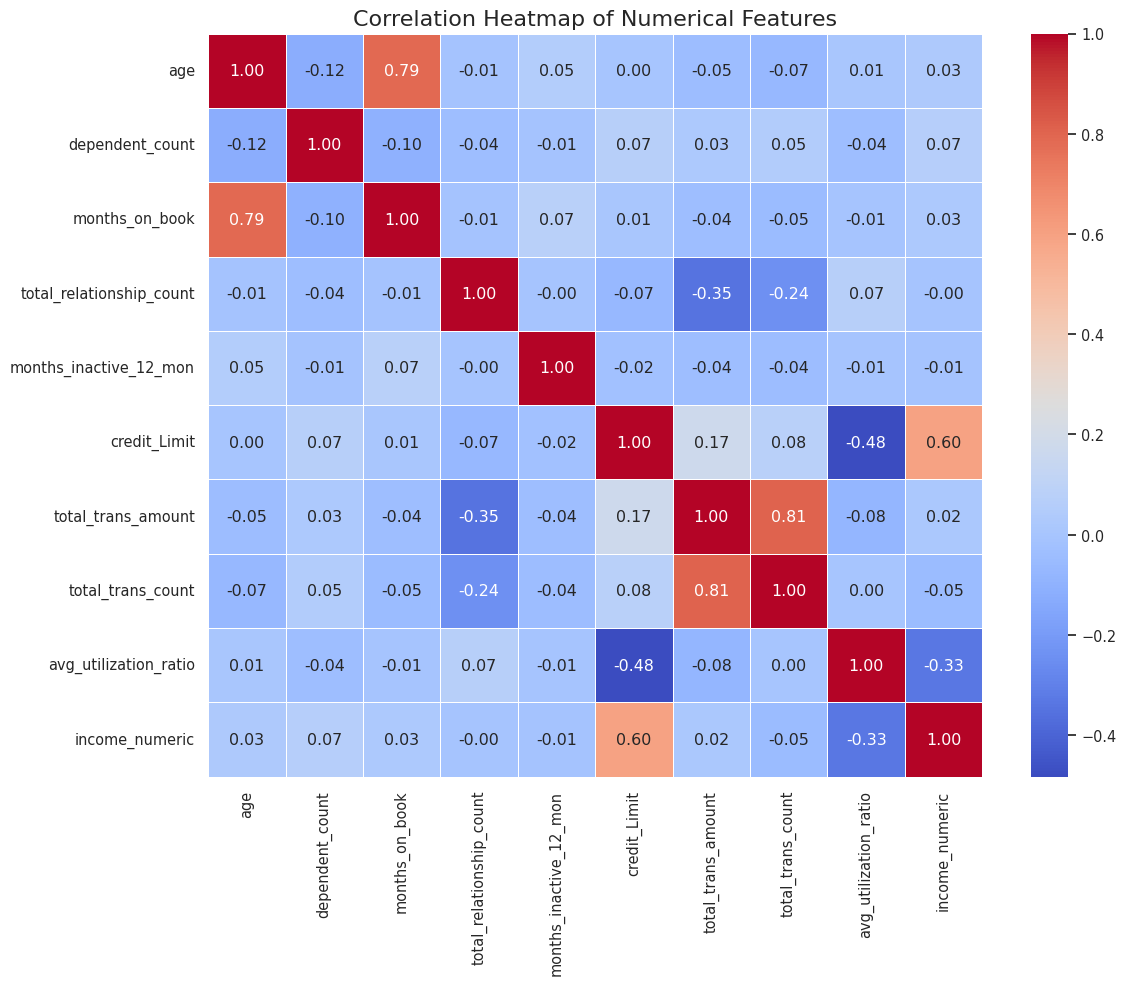

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(12, 10)) # Adjust figure size for better readability

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax)

# Set title
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=16)

plt.tight_layout()
plt.show()

* A strong positive correlation between age and months_on_book **(0.79)**, which makes intuitive sense as older customers are likely to have been with the bank longer.

* A very strong positive correlation between total_trans_amount and total_trans_count **(0.81)**, suggesting that customers who transact more often also tend to spend more in total.

* A moderate positive correlation between credit_limit and income_numeric **(0.60)**, indicating that higher-income customers generally have higher credit limits.

* A moderate negative correlation between credit_limit and avg_utilization_ratio **(-0.48)**, meaning customers with higher credit limits tend to utilize a smaller proportion of their available credit.

## **Feature Engineering**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

df_model = df.copy()

In [ ]:
# Check unknowns
print(df_model['education_level'].value_counts())
print(df_model['marital_status'].value_counts())

#Here we keep 'Unknown' as its own category (simplest, often fine)


education_level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64
marital_status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64


**Ordinal Encoding on Education Level Feature**

In [ ]:
education_order = [['Uneducated', 'High School', 'College', 'Graduate',
                     'Post-Graduate', 'Doctorate', 'Unknown']]

ord_enc = OrdinalEncoder(categories=education_order)
df_model['education_level_encoded'] = ord_enc.fit_transform(df_model[['education_level']])

In [ ]:
# Better: encode first, then treat 'Unknown' as missing and impute with median
df_model['education_level_encoded'] = df_model['education_level_encoded'].replace(6, np.nan)
df_model['education_level_encoded'] = df_model['education_level_encoded'].fillna(
    df_model['education_level_encoded'].median()
)

**One Hot encoding on Gender and Marital Status Feature**

In [ ]:
df_model = pd.get_dummies(df_model, columns=['gender', 'marital_status'],
                            prefix=['gender', 'marital'], drop_first=False)

**Scale Numerical features using Standard Scaler**

In [ ]:
numeric_cols = ['age', 'dependent_count', 'income_numeric', 'months_on_book',
                'total_relationship_count', 'months_inactive_12_mon',
                'credit_Limit', 'total_trans_amount', 'total_trans_count',
                'avg_utilization_ratio', 'education_level_encoded']

scaler = StandardScaler()
df_model[numeric_cols] = scaler.fit_transform(df_model[numeric_cols])

**Final Column selection for clustering task**
* Remove columns like Customer_ID, education_level (unencoded), estimated_income.

In [ ]:
onehot_cols = [c for c in df_model.columns if c.startswith('gender_') or c.startswith('marital_')]

feature_cols = numeric_cols + onehot_cols
X = df_model[feature_cols]

print(X.shape)
X.head()

(10127, 17)


,age,dependent_count,income_numeric,months_on_book,total_relationship_count,months_inactive_12_mon,credit_Limit,total_trans_amount,total_trans_count,avg_utilization_ratio,education_level_encoded,gender_F,gender_M,marital_Divorced,marital_Married,marital_Single,marital_Unknown
0,-0.165406,0.503368,0.340900,0.384621,0.763943,-1.327136,0.446622,-0.959707,-0.973895,-0.775882,-0.807534,False,True,False,True,False,False
1,0.333570,2.043199,-0.973451,1.010715,1.407306,-1.327136,-0.041367,-0.916433,-1.357340,-0.616276,0.727789,True,False,False,False,True,False
2,0.583058,0.503368,1.129511,0.008965,0.120579,-1.327136,-0.573698,-0.740982,-1.911206,-0.997155,0.727789,False,True,False,True,False,False
3,-0.789126,1.273283,-0.973451,-0.241473,-0.522785,1.641478,-0.585251,-0.951758,-1.911206,1.759686,-0.807534,True,False,False,False,False,True
4,-0.789126,0.503368,0.340900,-1.869317,0.763943,-1.327136,-0.430877,-1.056263,-1.570365,-0.997155,-1.575195,False,True,False,True,False,False


### **Determining Optimal K: Elbow Method and Silhouette Score**

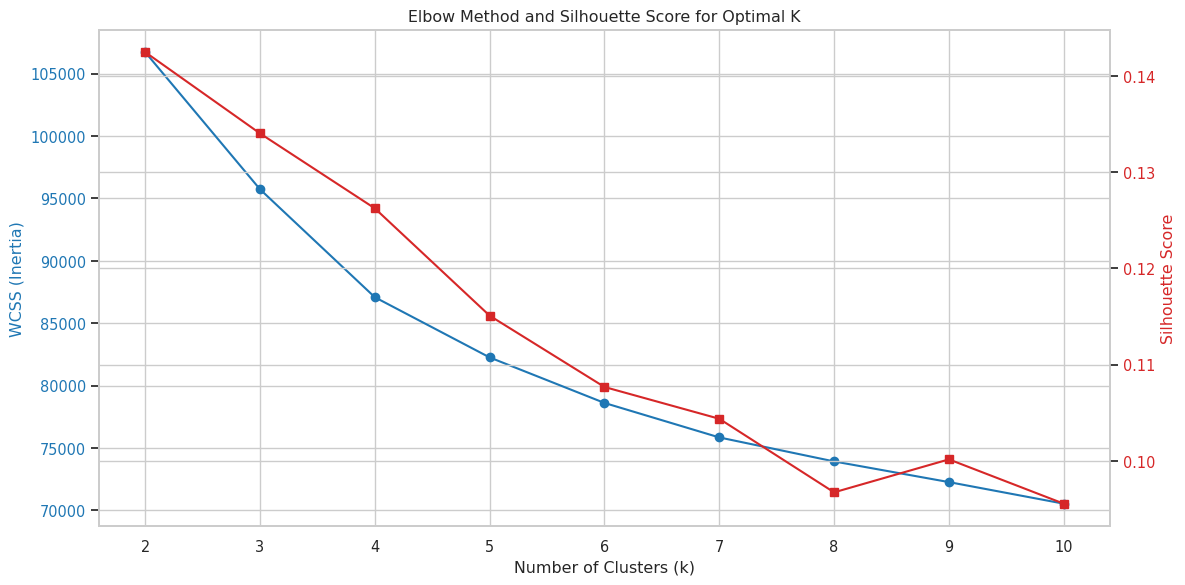

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

# Impute NaNs in X before clustering
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_imputed)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_imputed, kmeans.labels_))

# Plotting the results
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(K_range, wcss, marker='o', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score for Optimal K')
fig.tight_layout()
plt.show()

### **Applying K-Means with K=4**

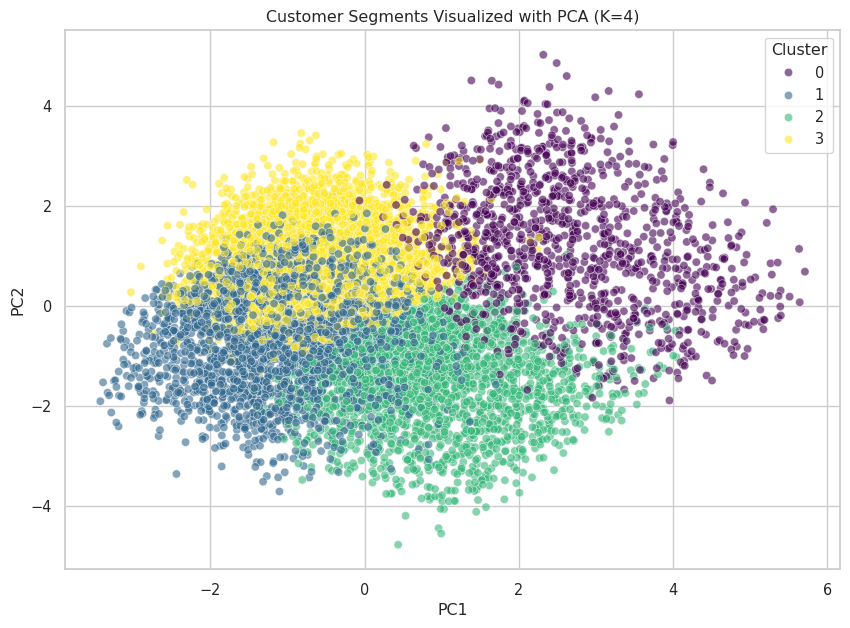

In [ ]:
from sklearn.decomposition import PCA

# Fit K-Means
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_imputed)

# Add cluster labels to the original and model dataframes
df['cluster'] = clusters
df_model['cluster'] = clusters

# Reduce dimensions to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_imputed)

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', alpha=0.6)
plt.title('Customer Segments Visualized with PCA (K=4)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [ ]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance (PC1+PC2):", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.18227302 0.16191461]
Total variance (PC1+PC2): 0.3441876280541847


Variance PC1-3: [0.18227302 0.16191461 0.14726723] Total: 0.4914548594035689


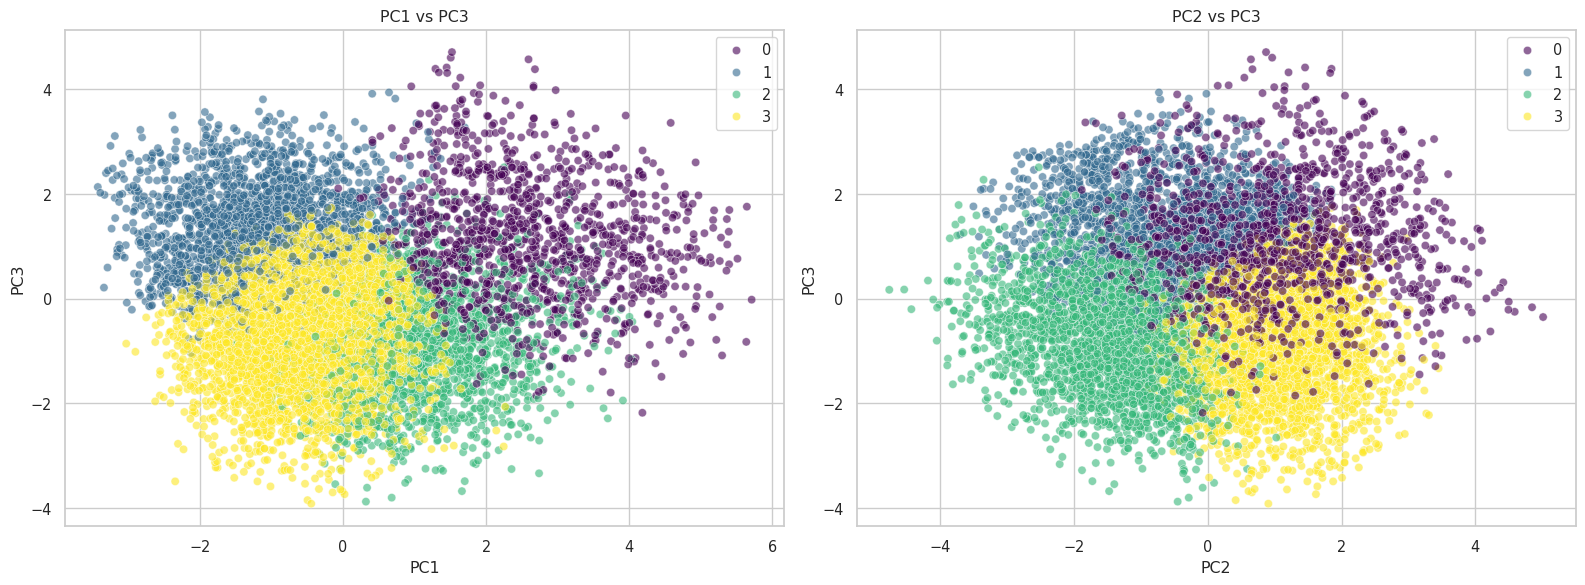

In [ ]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_imputed)
print("Variance PC1-3:", pca3.explained_variance_ratio_, "Total:", sum(pca3.explained_variance_ratio_))

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.scatterplot(x=X_pca3[:,0], y=X_pca3[:,2], hue=clusters, palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC3'); axes[0].set_title('PC1 vs PC3')

sns.scatterplot(x=X_pca3[:,1], y=X_pca3[:,2], hue=clusters, palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_xlabel('PC2'); axes[1].set_ylabel('PC3'); axes[1].set_title('PC2 vs PC3')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_imputed, clusters)
df['silhouette'] = sil_vals

print("Overall silhouette:", silhouette_score(X_imputed, clusters))
print("\nPer-cluster mean silhouette:")
print(df.groupby('cluster')['silhouette'].mean().sort_values())

print("\nCluster sizes:")
print(df['cluster'].value_counts())

Overall silhouette: 0.1262542516835599

Per-cluster mean silhouette:
cluster
3    0.116776
1    0.118488
2    0.135730
0    0.156499
Name: silhouette, dtype: float64

Cluster sizes:
cluster
3    4046
1    2491
2    2450
0    1140
Name: count, dtype: int64


##**Labeling Clusters**

In [ ]:
profile_cols = ['age', 'income_numeric', 'credit_Limit', 'total_trans_amount',
                 'total_trans_count', 'avg_utilization_ratio',
                 'total_relationship_count', 'months_inactive_12_mon',
                 'months_on_book', 'dependent_count']

cluster_profile = df.groupby('cluster')[profile_cols].mean().round(2)
print(cluster_profile)

           age  income_numeric  credit_Limit  total_trans_amount  \
cluster                                                            
0        45.35        66038.46      14832.71            12429.08   
1        55.09        40554.52       4338.60             3305.87   
2        46.28        99927.16      17595.48             3090.33   
3        41.23        35822.60       4100.38             3614.63   

         total_trans_count  avg_utilization_ratio  total_relationship_count  \
cluster                                                                       
0                   103.23                   0.16                      2.11   
1                    58.62                   0.36                      3.98   
2                    55.47                   0.09                      4.12   
3                    63.57                   0.37                      4.00   

         months_inactive_12_mon  months_on_book  dependent_count  
cluster                                          

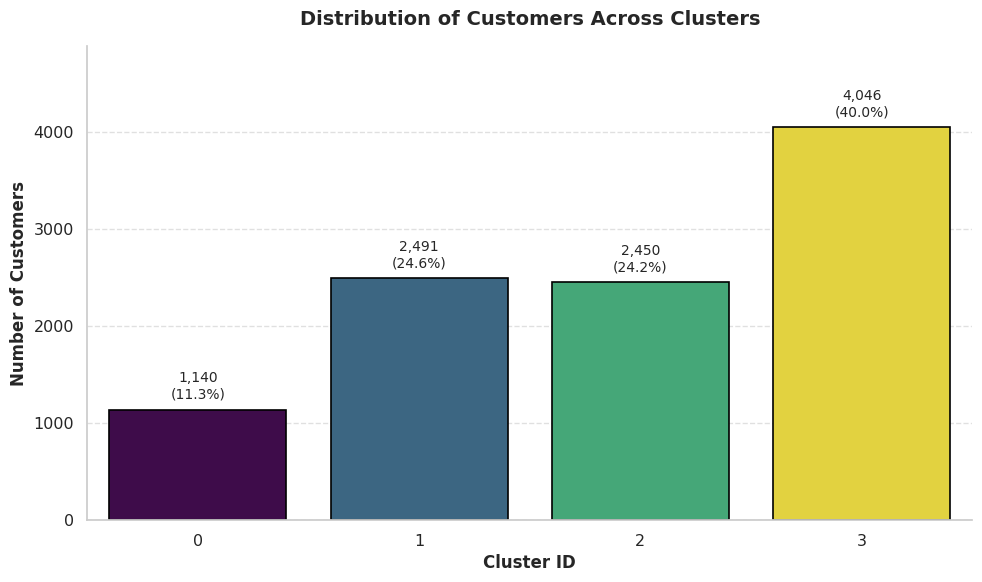

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall theme for a cleaner look
sns.set_theme(style='whitegrid', font_scale=1.05)

plt.figure(figsize=(10, 6))

# Calculate total number of customers for percentages
total_customers = len(df)

# Create the countplot with defined edge colors
ax = sns.countplot(
    x='cluster',
    data=df,
    palette='viridis',
    hue='cluster',
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

# Clean and bold titles/labels
plt.title('Distribution of Customers Across Clusters', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cluster ID', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')

# Add data labels (counts and percentages) to each bar
for p in ax.patches:
    height = p.get_height()
    # Prevent division by zero if dataframe is empty
    percentage = (height / total_customers) * 100 if total_customers > 0 else 0

    ax.annotate(
        f'{int(height):,}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 6),
        textcoords='offset points'
    )

# Expand y-axis limit dynamically so annotations don't get clipped
current_bottom, current_top = ax.get_ylim()
ax.set_ylim(current_bottom, current_top * 1.15)

# Refine grid and remove top/right box borders
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.show()

### **Cluster Profiling: Comparing Average Features**

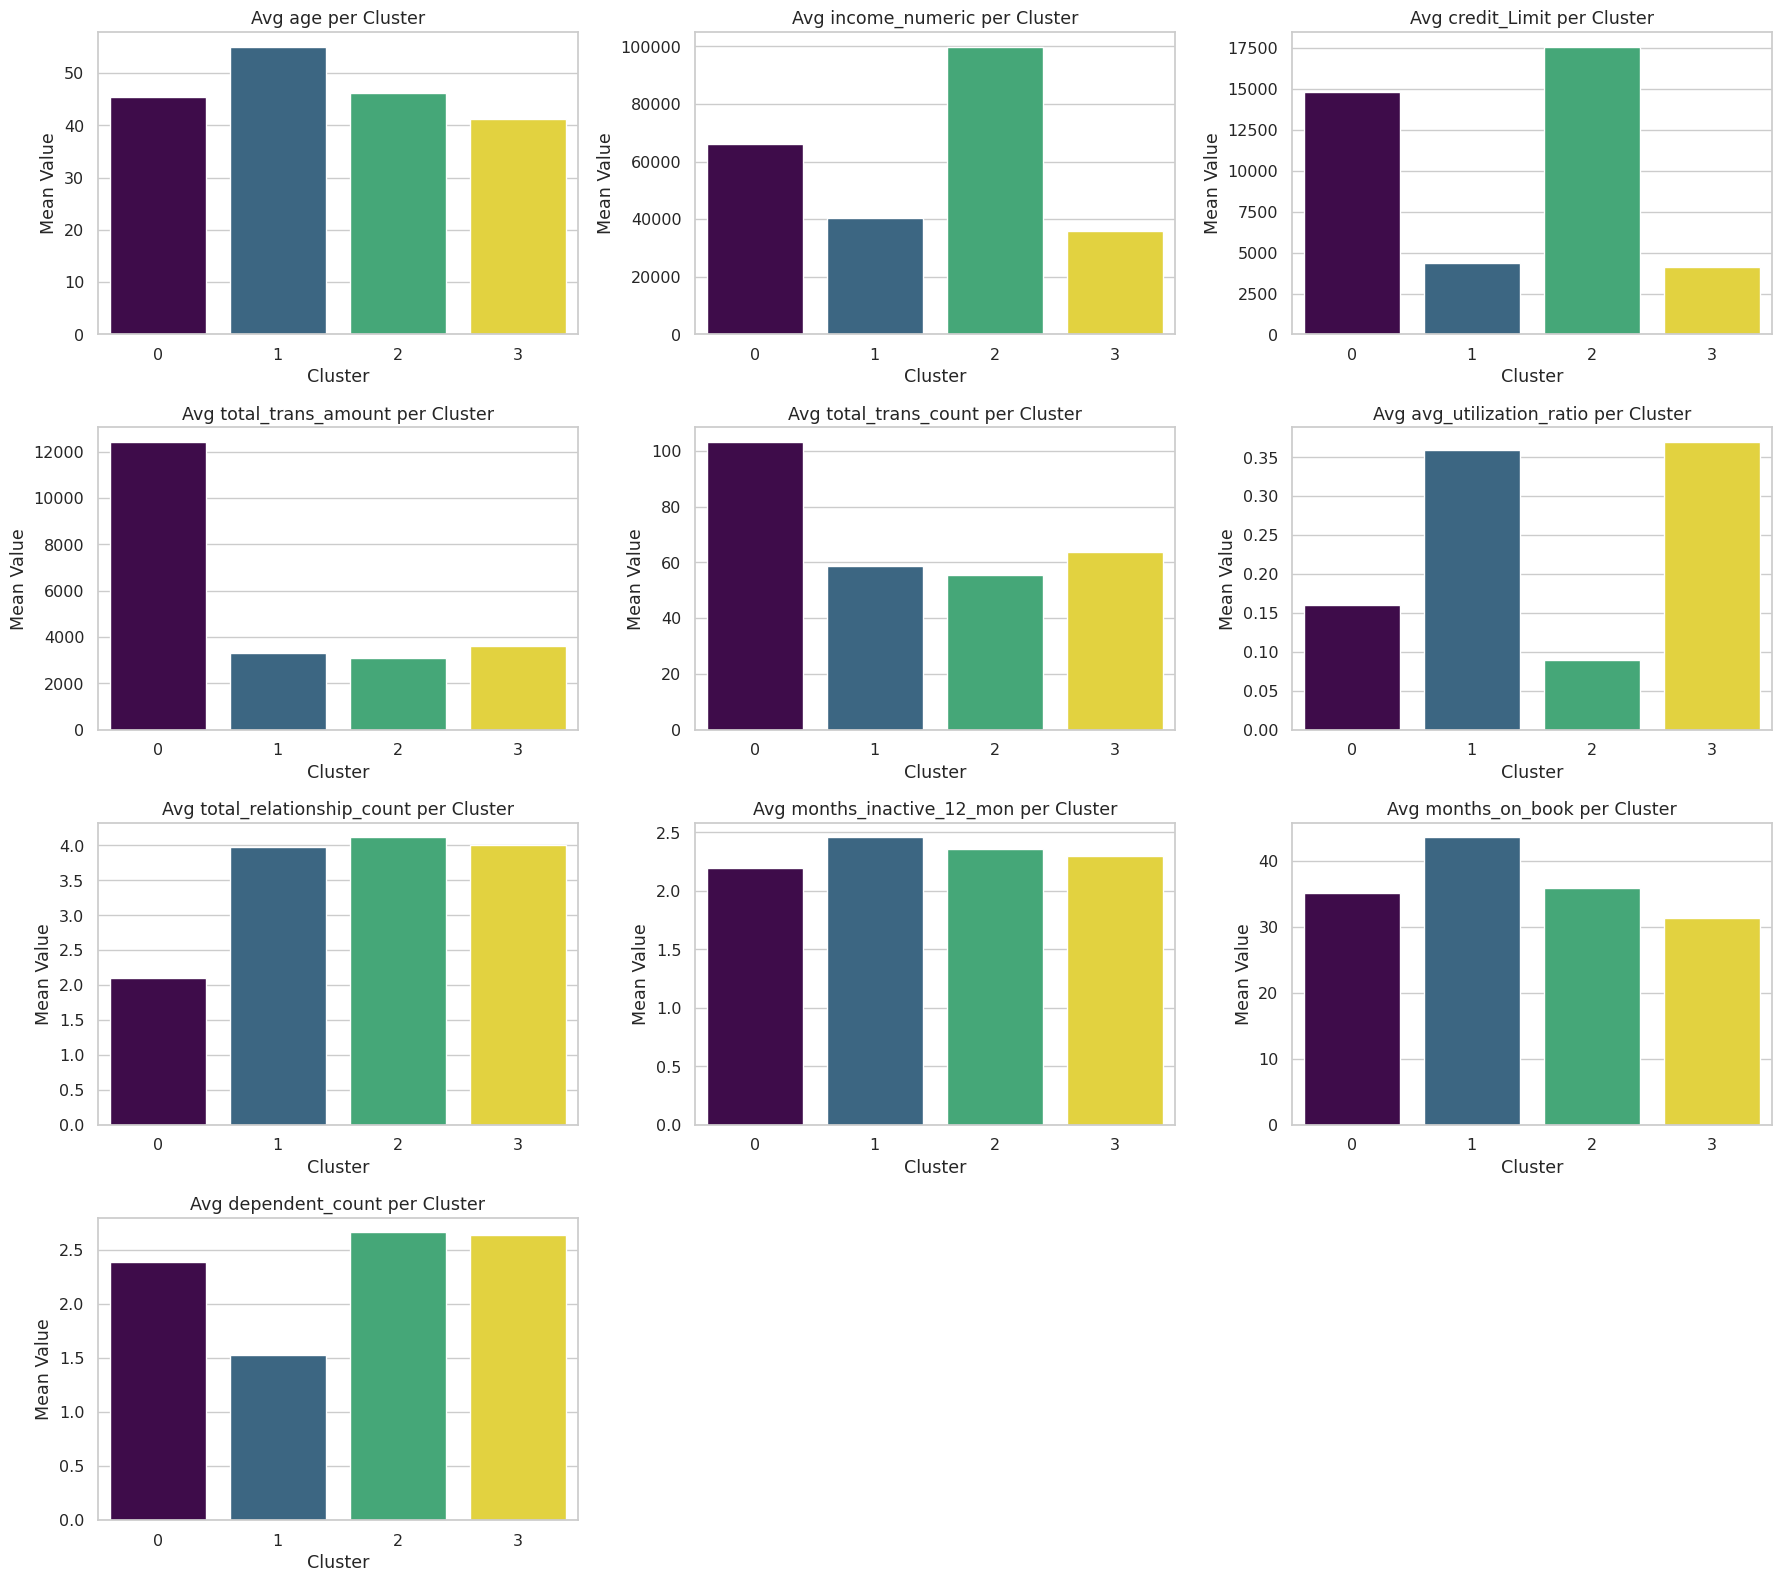

In [ ]:
import math

# Using the previously defined profile_cols
num_plots = len(profile_cols)
cols_per_row = 3
rows = math.ceil(num_plots / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()

for i, col in enumerate(profile_cols):
    sns.barplot(x=cluster_profile.index, y=col, data=cluster_profile, ax=axes[i], palette='viridis', hue=cluster_profile.index, legend=False)
    axes[i].set_title(f'Avg {col} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Mean Value')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##Based on these visualizations, here is a breakdown of our four customer segments:

* **Cluster 0 (Purple):** The High-Value Spenders. These customers have the highest transaction amounts and counts, and a high credit limit, despite being middle-aged.
* **Cluster 1 (Blue):** The Loyal Seniors. This group is the oldest on average and has been with the bank the longest (highest 'months_on_book'). They have low spending and lower credit limits.
* **Cluster 02 (Green):** The High-Income Professionals. These customers have the highest average income and credit limits, but their transaction counts are relatively low.
* **Cluster 3 (Yellow):** The Young Active Users. This is our largest group. They are younger, have lower incomes and credit limits, but show high utilization and frequent (though smaller) transactions.

### **Applying Business Labels to Clusters**

* **Cluster 0** is our **Everyday Customers** because they are frequent Spenders also they have High transaction count and high transaction amount.
* **Cluster 1** is our **Credit Constrained heavy users** because they are mostly old age customers they are using credit cards for a long time also they have low spendings because they have limited credits.
* **Cluster 2** is our **Under Utilizer Customers** because they are rich high income peoples they have very high income as well as high credits but they are not utilize credit card as their limits.
* **Cluster 3** is our **High Utilization Cutomers** mostly in this cluster is youth also this is largest segment across the dataset they have lower income as they have lower limit but they mostly utilize all credits.

In [ ]:
cluster_map = {
    0: 'Everyday Customers',
    1: 'Credit-Constrained Heavy Users',
    2: 'Under Utilizer customers',
    3: 'High Utilization Customers'
}

df['cluster_label'] = df['cluster'].map(cluster_map)
df_model['cluster_label'] = df_model['cluster'].map(cluster_map)

# Displaying the count of each labeled segment
display(df['cluster_label'].value_counts().to_frame())

# Showing a sample of the data with labels
display(df[['customer_id', 'age', 'marital_status', 'income_numeric', 'cluster_label']].head(10))

,count
cluster_label,
High Utilization Customers,4046
Credit-Constrained Heavy Users,2491
Under Utilizer customers,2450
Everyday Customers,1140


,customer_id,age,marital_status,income_numeric,cluster_label
0,768805383,45,Married,70000.0,Under Utilizer customers
1,818770008,49,Single,20000.0,High Utilization Customers
2,713982108,51,Married,100000.0,Under Utilizer customers
3,769911858,40,Unknown,20000.0,High Utilization Customers
4,709106358,40,Married,70000.0,High Utilization Customers
5,713061558,44,Married,50000.0,High Utilization Customers
6,810347208,51,Married,140000.0,Under Utilizer customers
7,818906208,32,Unknown,70000.0,Under Utilizer customers
8,710930508,37,Single,70000.0,Under Utilizer customers
9,719661558,48,Single,100000.0,Under Utilizer customers


### **Hierarchical Clustering**
We will use the Ward linkage method, which minimizes the variance of clusters being merged. First, let's visualize the dendrogram.

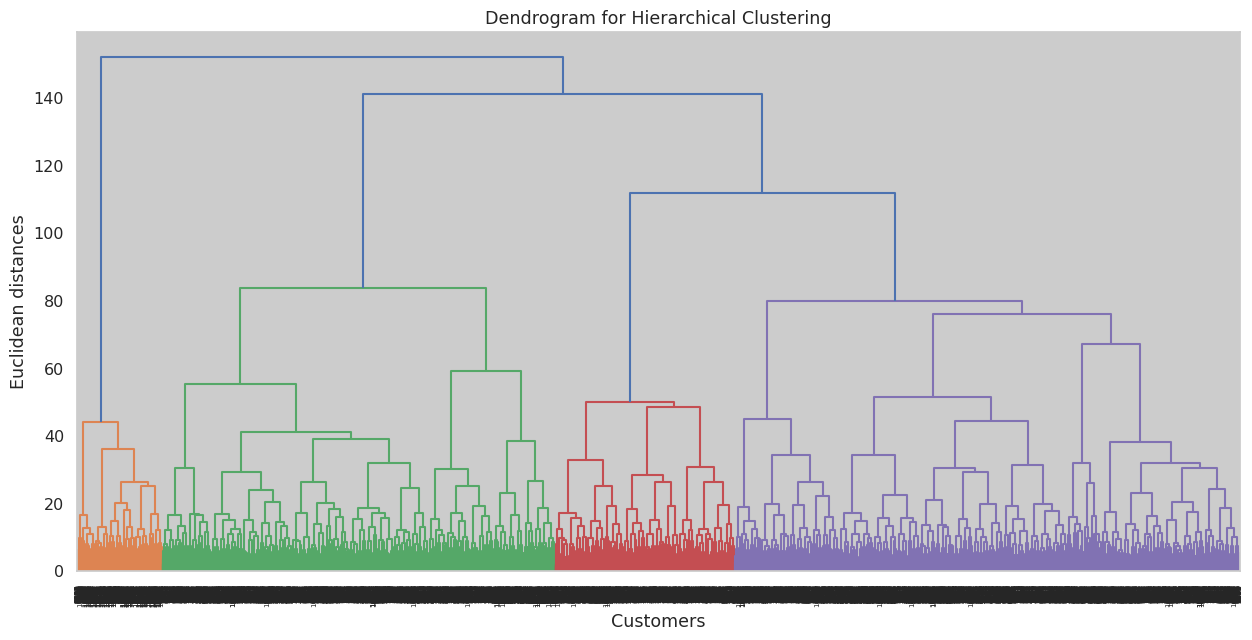

In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Generate Dendrogram
plt.figure(figsize=(15, 7))
dendrogram = sch.dendrogram(sch.linkage(X_imputed, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

Now we apply the Agglomerative Clustering model using 4 clusters.

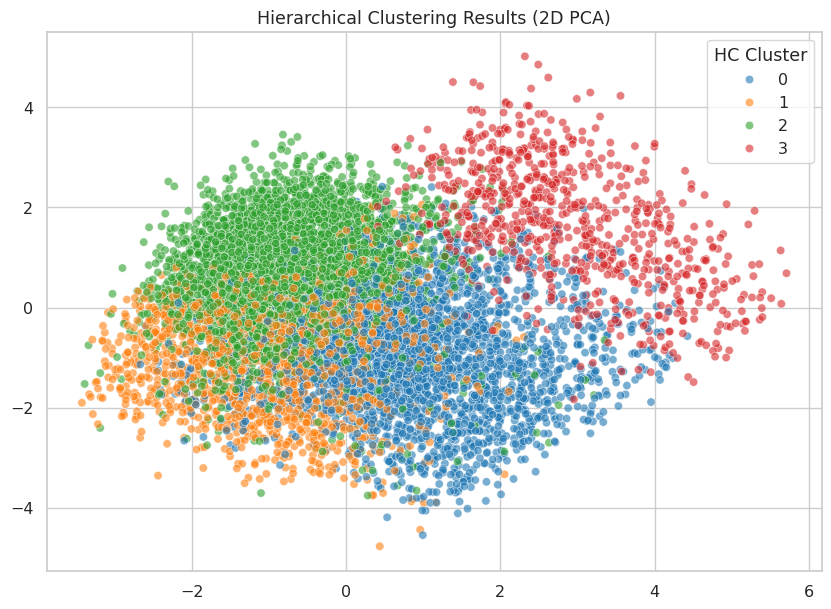

In [ ]:
# Fit Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_imputed)

# Add to DataFrame
df['hierarchical_cluster'] = y_hc

# Visualize the Hierarchical Clusters using the first two Principal Components
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_hc, palette='tab10', alpha=0.6)
plt.title('Hierarchical Clustering Results (2D PCA)')
plt.legend(title='HC Cluster')
plt.grid(True)
plt.show()

In [ ]:
print("Hierarchical Cluster Sizes:")
display(df['hierarchical_cluster'].value_counts().to_frame())

Hierarchical Cluster Sizes:


,count
hierarchical_cluster,
2,4397
0,3423
1,1564
3,743


### **Comparison: K-Means vs. Hierarchical Clustering Profiles**
We will compare the average feature values of the clusters produced by both methods to see if the segments represent similar customer behaviors.

In [ ]:
# Calculate profiles for Hierarchical Clusters
hc_cluster_profile = df.groupby('hierarchical_cluster')[profile_cols].mean().round(2)

print("K-Means Cluster Profiles (Mean Values):")
display(cluster_profile)
print("\nHierarchical Cluster Profiles (Mean Values):")
display(hc_cluster_profile)

K-Means Cluster Profiles (Mean Values):


,age,income_numeric,credit_Limit,total_trans_amount,total_trans_count,avg_utilization_ratio,total_relationship_count,months_inactive_12_mon,months_on_book,dependent_count
cluster,,,,,,,,,,
0,45.35,66038.46,14832.71,12429.08,103.23,0.16,2.11,2.20,35.15,2.39
1,55.09,40554.52,4338.60,3305.87,58.62,0.36,3.98,2.46,43.63,1.53
2,46.28,99927.16,17595.48,3090.33,55.47,0.09,4.12,2.36,35.92,2.66
3,41.23,35822.60,4100.38,3614.63,63.57,0.37,4.00,2.30,31.41,2.64



Hierarchical Cluster Profiles (Mean Values):


,age,income_numeric,credit_Limit,total_trans_amount,total_trans_count,avg_utilization_ratio,total_relationship_count,months_inactive_12_mon,months_on_book,dependent_count
hierarchical_cluster,,,,,,,,,,
0,45.37,88832.98,14162.61,3658.04,60.34,0.17,3.88,2.30,35.06,2.65
1,55.69,46203.01,6115.13,3039.91,54.60,0.26,4.28,2.11,44.41,1.48
2,43.95,31472.57,4302.08,3734.42,64.32,0.38,3.84,2.48,33.74,2.43
3,45.10,62992.70,14073.88,14675.74,110.44,0.18,2.36,2.21,35.00,2.25


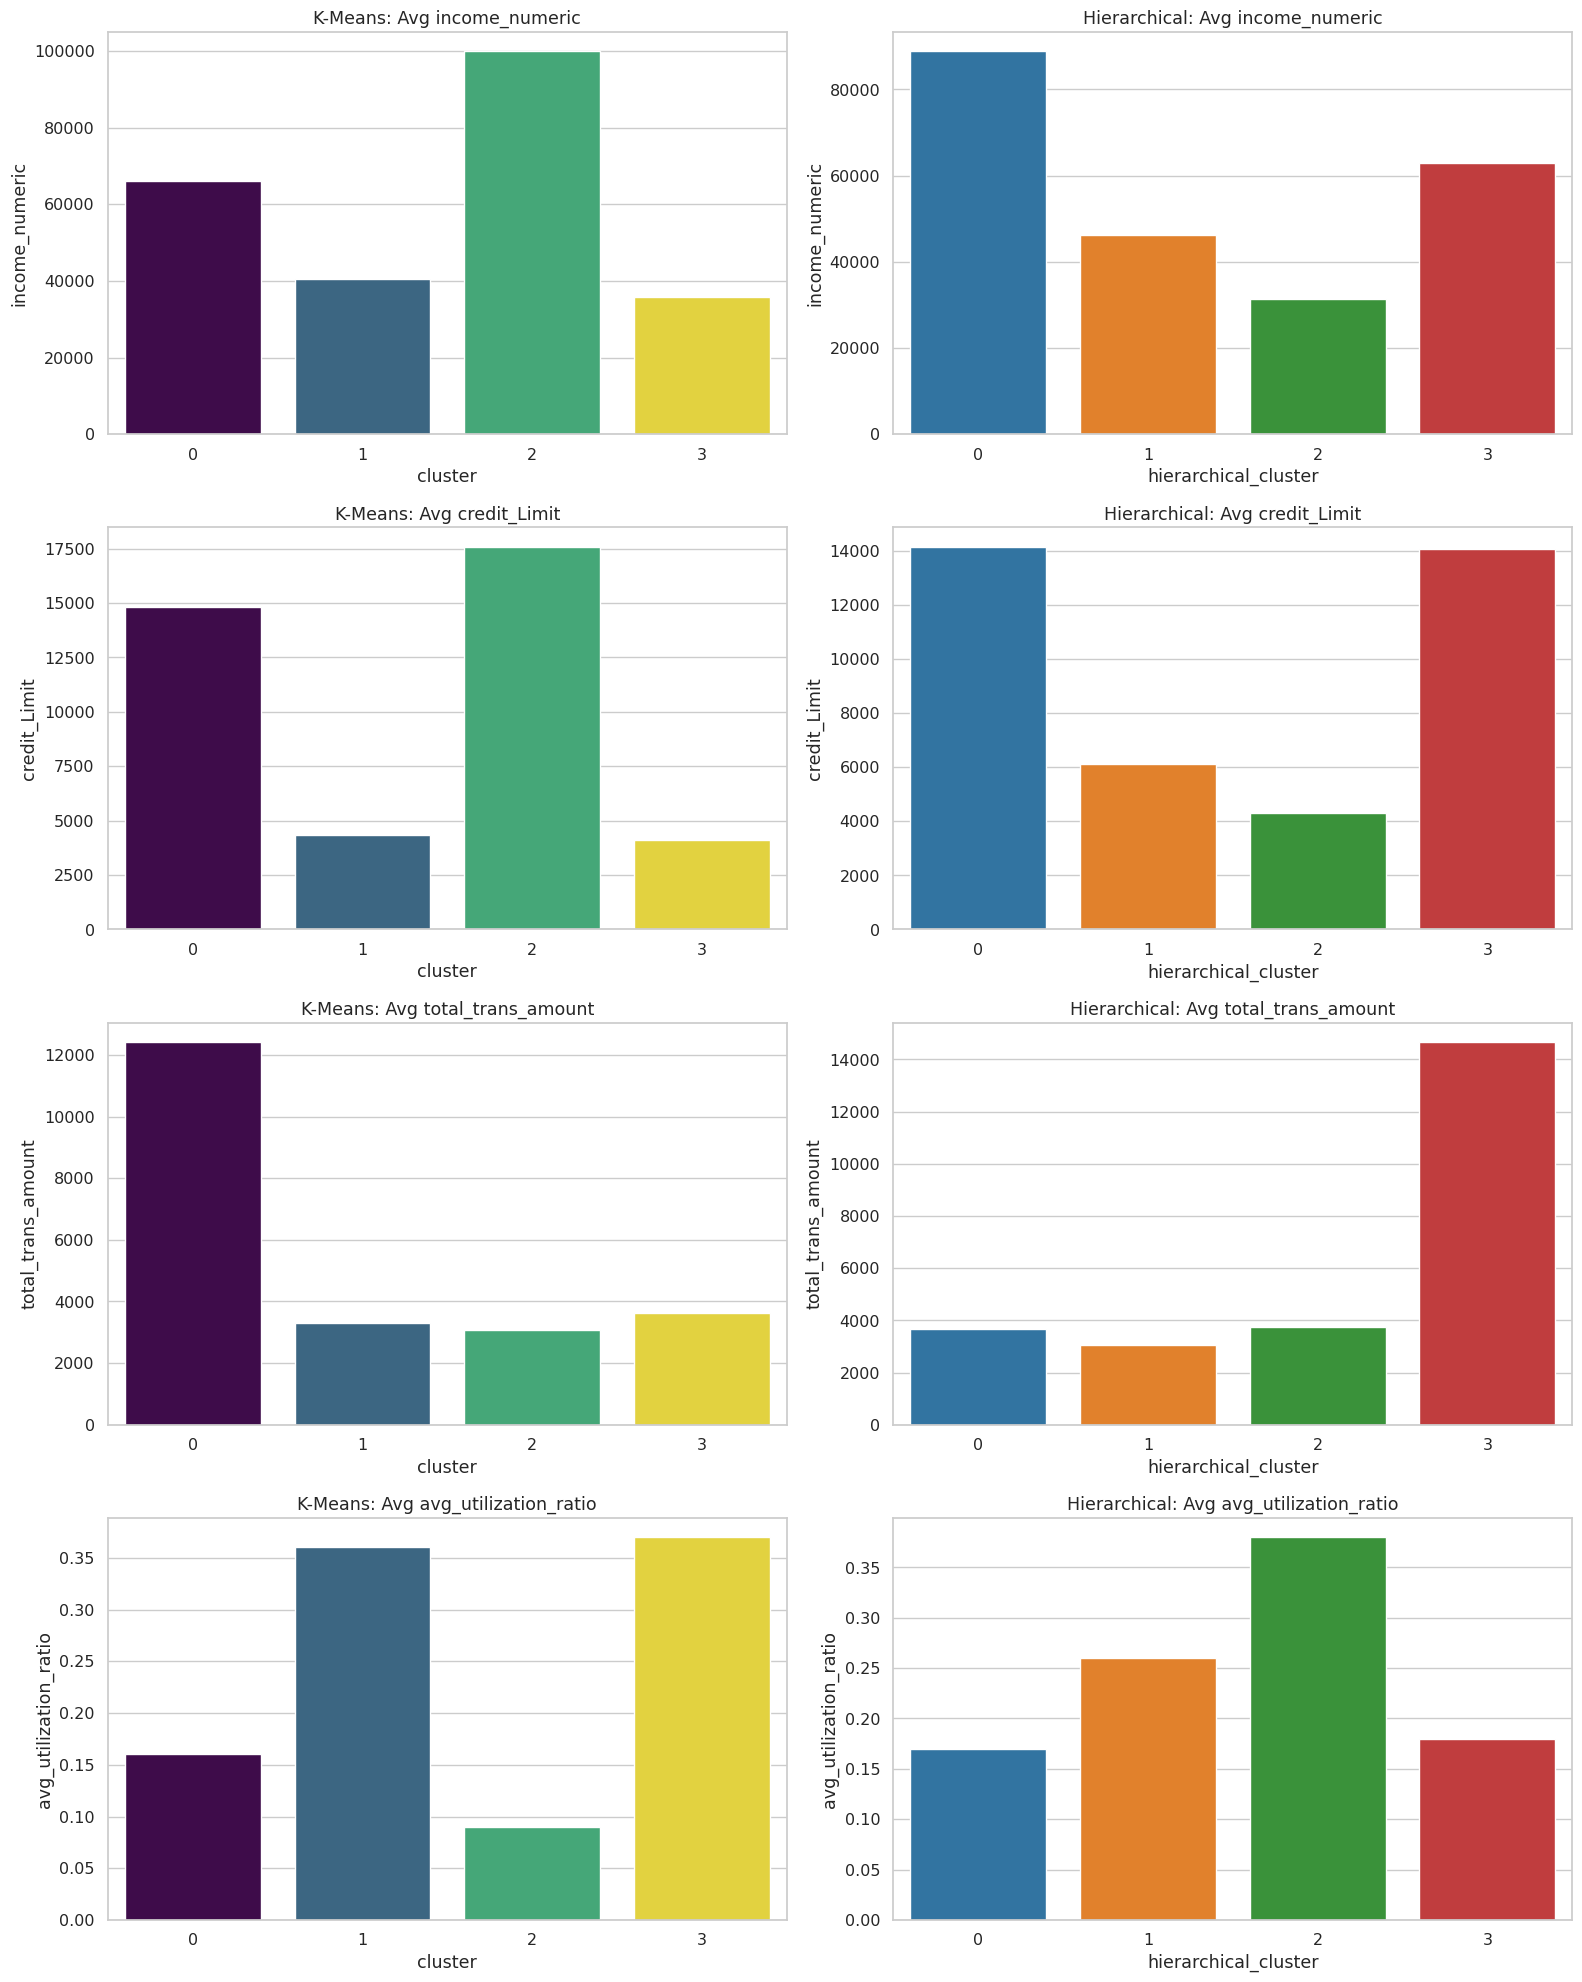

In [ ]:
# Visual Comparison of a few key metrics
comparison_features = ['income_numeric', 'credit_Limit', 'total_trans_amount', 'avg_utilization_ratio']

fig, axes = plt.subplots(len(comparison_features), 2, figsize=(16, 20))

for i, col in enumerate(comparison_features):
    # K-Means Plot
    sns.barplot(x=cluster_profile.index, y=col, data=cluster_profile, ax=axes[i, 0], palette='viridis', hue=cluster_profile.index, legend=False)
    axes[i, 0].set_title(f'K-Means: Avg {col}')

    # Hierarchical Plot
    sns.barplot(x=hc_cluster_profile.index, y=col, data=hc_cluster_profile, ax=axes[i, 1], palette='tab10', hue=hc_cluster_profile.index, legend=False)
    axes[i, 1].set_title(f'Hierarchical: Avg {col}')

plt.tight_layout()
plt.show()

##**Here Based On Analysis:**
###K-Means: Successfully identified 4 clear business segments, ranging from 'High Utilization' to 'Everyday' customers. This provided the most interpretable results for business strategy.
###Hierarchical Clustering: Validated the 4-cluster structure using the Ward linkage method and provided a detailed view of customer similarity via the dendrogram.